<a href="https://colab.research.google.com/github/sebastianvettel1212/GrokkingDeepLearning/blob/main/06_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 6 — *Backpropagation*: Membangun Deep Neural Network Pertama (*Building Your First DEEP Neural Network*)

**Buku:** *Grokking Deep Learning* — Andrew W. Trask (Manning, 2019)

Kita membangun neural network **dalam (*deep*)** pertama pada ***streetlight problem***, dan menurunkan *backpropagation*: cara membagikan error ke bobot pada layer yang tidak langsung terhubung ke output. Kode diambil dari repositori resmi buku, ditambah teori dan beberapa eksperimen (berlabel *Tambahan*).

---

## Daftar Isi
1. *Streetlight Problem* dan Matriks Data
2. Belajar dari Satu Contoh
3. Belajar dari Seluruh Dataset
4. Tekanan Naik-Turun (*Up and Down Pressure*) dan Korelasi
5. Korelasi Tidak Langsung dan *Hidden Layer*
6. Jaringan Dalam Pertama
7. *Backpropagation* dalam Kode
8. Satu Iterasi *Backpropagation* + Verifikasi Gradien Numerik
9. Menyatukan Semuanya, Versi *Full Batch*, dan Ukuran *Hidden Layer*
10. Ringkasan Bab

## 1. *Streetlight Problem* dan Matriks Data

Skenario: kita harus menentukan **jalan (*walk*) atau berhenti (*stop*)** di persimpangan berdasarkan **tiga lampu lalu lintas** (kiri, tengah, kanan; 1 = menyala, 0 = mati). Datanya berupa **matriks**: setiap baris adalah satu contoh, setiap kolom satu lampu. Target `walk_vs_stop`: 1 = jalan, 0 = berhenti.

Dalam pandangan *machine learning*, tugas jaringan adalah **menemukan korelasi** antara pola lampu dan keputusan.

---
## 2. Belajar dari Satu Contoh

Mulai dari jaringan 1-layer dan **satu contoh data** (`streetlights[0] = [1,0,1]`, target 0). Ini persis *gradient descent* dengan banyak input (Bab 5).

In [1]:
import numpy as np
weights = np.array([0.5,0.48,-0.7])
alpha = 0.1

streetlights = np.array( [ [ 1, 0, 1 ],
                           [ 0, 1, 1 ],
                           [ 0, 0, 1 ],
                           [ 1, 1, 1 ],
                           [ 0, 1, 1 ],
                           [ 1, 0, 1 ] ] )

walk_vs_stop = np.array( [ 0, 1, 0, 1, 1, 0 ] )

input = streetlights[0] # [1,0,1]
goal_prediction = walk_vs_stop[0] # equals 0... i.e. "stop"

for iteration in range(20):
    prediction = input.dot(weights)
    error = (goal_prediction - prediction) ** 2
    delta = prediction - goal_prediction
    weights = weights - (alpha * (input * delta))

    print("Error:" + str(error) + " Prediction:" + str(prediction))

Error:0.03999999999999998 Prediction:-0.19999999999999996
Error:0.025599999999999973 Prediction:-0.15999999999999992
Error:0.01638399999999997 Prediction:-0.1279999999999999
Error:0.010485759999999964 Prediction:-0.10239999999999982
Error:0.006710886399999962 Prediction:-0.08191999999999977
Error:0.004294967295999976 Prediction:-0.06553599999999982
Error:0.002748779069439994 Prediction:-0.05242879999999994
Error:0.0017592186044416036 Prediction:-0.04194304000000004
Error:0.0011258999068426293 Prediction:-0.03355443200000008
Error:0.0007205759403792803 Prediction:-0.02684354560000002
Error:0.0004611686018427356 Prediction:-0.021474836479999926
Error:0.0002951479051793508 Prediction:-0.01717986918399994
Error:0.00018889465931478573 Prediction:-0.013743895347199997
Error:0.00012089258196146188 Prediction:-0.010995116277759953
Error:7.737125245533561e-05 Prediction:-0.008796093022207963
Error:4.951760157141604e-05 Prediction:-0.007036874417766459
Error:3.169126500570676e-05 Prediction:-0.0

**Interpretasi:** error turun hingga hampir 0 untuk contoh ini. Namun jaringan hanya belajar **satu contoh** dan belum tentu benar untuk contoh lain.

### Operasi vektor NumPy

In [2]:
import numpy as np

a = np.array([0,1,2,1])
b = np.array([2,2,2,3])

print(a*b) #elementwise multiplication
print(a+b) #elementwise addition
print(a * 0.5) # vector-scalar multiplication
print(a + 0.5) # vector-scalar addition

[0 2 4 3]
[2 3 4 4]
[0.  0.5 1.  0.5]
[0.5 1.5 2.5 1.5]


---
## 3. Belajar dari Seluruh Dataset

Agar jaringan menangkap pola semua contoh, kita ulangi pembelajaran pada **setiap baris** dalam satu **iterasi/epoch**. Ini disebut ***stochastic gradient descent*** (bobot diperbarui **setelah tiap contoh**). Alternatifnya:

| Metode | Kapan bobot diperbarui |
|---|---|
| **Stochastic GD** | Setelah **setiap contoh** (di sini) |
| **Full batch GD** | Setelah **seluruh dataset** (rata-rata gradien) |
| **Batch GD (mini-batch)** | Setelah **sekelompok contoh** (mis. 100) |

*(Kode buku mencetak setiap prediksi; di sini hanya error total tiap beberapa epoch agar ringkas.)*

In [3]:
import numpy as np

weights = np.array([0.5,0.48,-0.7])
alpha = 0.1

streetlights = np.array( [[ 1, 0, 1 ],
                          [ 0, 1, 1 ],
                          [ 0, 0, 1 ],
                          [ 1, 1, 1 ],
                          [ 0, 1, 1 ],
                          [ 1, 0, 1 ] ] )

walk_vs_stop = np.array( [ 0, 1, 0, 1, 1, 0 ] )

input = streetlights[0] # [1,0,1]
goal_prediction = walk_vs_stop[0] # equals 0... i.e. "stop"

for iteration in range(40):
    error_for_all_lights = 0
    for row_index in range(len(walk_vs_stop)):
        input = streetlights[row_index]
        goal_prediction = walk_vs_stop[row_index]

        prediction = input.dot(weights)

        error = (goal_prediction - prediction) ** 2
        error_for_all_lights += error

        delta = prediction - goal_prediction
        weights = weights - (alpha * (input * delta))
    if iteration % 5 == 0 or iteration == 39:
        print("Iterasi " + str(iteration) + " | Error:" + str(error_for_all_lights))

print("\nBobot akhir:", weights.round(3))

Iterasi 0 | Error:2.6561231104
Iterasi 5 | Error:0.17797575048089034
Iterasi 10 | Error:0.04394763937673939
Iterasi 15 | Error:0.016952094519447087
Iterasi 20 | Error:0.00786904226904208
Iterasi 25 | Error:0.0038385124412518303
Iterasi 30 | Error:0.0018939739123713475
Iterasi 35 | Error:0.0009368896209360312
Iterasi 39 | Error:0.00053373677328488

Bobot akhir: [ 0.014  1.014 -0.016]


**Interpretasi:** error total turun mendekati 0 dan bobot akhir ≈ `[0, 1, 0]`: jaringan menemukan bahwa **hanya lampu tengah** yang berkorelasi dengan keputusan "jalan".

---
## 4. Tekanan Naik-Turun (*Up and Down Pressure*) dan Korelasi

Setiap data memberi **tekanan** pada bobot: jika input menyala saat target = 1, bobot ditekan **naik**; jika menyala saat target = 0, ditekan **turun**. Bobot akhir adalah **hasil adu tekanan** dari seluruh contoh. Bobot positif besar berarti korelasi positif; bobot negatif berarti korelasi negatif; bobot ≈ 0 berarti tidak berkorelasi. Jadi **jaringan belajar korelasi**.

### *Edge case*: *overfitting* dan *conflicting pressure*
- ***Overfitting*:** bila ada banyak cara menghasilkan error 0, jaringan bisa memilih korelasi yang kebetulan cocok pada data latih tetapi tidak berlaku umum. Tambahan data dan regulasi (Bab 8) membantu.
- ***Conflicting pressure*:** bila tekanan naik dan turun pada satu bobot saling meniadakan (mis. lampu kiri menyala setengah waktu saat jalan dan setengah saat berhenti), bobot ≈ 0 dan korelasi tidak ditemukan.

---
## 5. Korelasi Tidak Langsung dan *Hidden Layer*

Bagaimana bila **tidak ada korelasi langsung** antara input dan target? Pada dataset 4 baris berikut (`walk_vs_stop = [1, 1, 0, 0]`):

| Kiri | Tengah | Kanan | Aksi |
|---|---|---|---|
| 1 | 0 | 1 | jalan (1) |
| 0 | 1 | 1 | jalan (1) |
| 0 | 0 | 1 | berhenti (0) |
| 1 | 1 | 1 | berhenti (0) |

Pola sebenarnya: **jalan bila tepat satu dari lampu kiri/tengah menyala** (mirip XOR); lampu kanan selalu menyala sehingga tidak informatif. Tidak ada satu lampu pun yang berkorelasi langsung dengan aksi: tiap lampu menyala sebagian waktu saat jalan dan sebagian waktu saat berhenti (**korelasi tidak langsung**, *"sometimes correlation"*). Solusinya ***hidden layer***, yang **menciptakan korelasi perantara**: layer tersembunyi menangkap kombinasi input (mis. "kiri menyala dan tengah mati") yang kemudian berkorelasi langsung dengan target.

### Mengapa perlu nonlinearitas?
Dua layer **linear** sama dengan **satu layer linear** (perkalian dua matriks adalah satu matriks), jadi tidak bisa menangkap korelasi tidak langsung. Dibutuhkan **fungsi aktivasi nonlinear**, salah satunya **ReLU** (*Rectified Linear Unit*):
$$\text{relu}(x)=\max(0,x)$$
ReLU "mematikan" korelasi negatif: node hanya ikut berkontribusi bila input terbobot positif, sehingga membuat korelasi yang berlaku **hanya kadang-kadang** (*sometimes correlation*).

In [4]:
# Tambahan (tidak ada di buku): dua layer LINEAR (tanpa ReLU) tidak bisa belajar pola tidak langsung
import numpy as np
np.random.seed(1)

lights = np.array([[1,0,1],[0,1,1],[0,0,1],[1,1,1]])
walk   = np.array([[1,1,0,0]]).T
w01 = 2*np.random.random((3,4)) - 1
w12 = 2*np.random.random((4,1)) - 1
alpha = 0.05

for it in range(2000):
    err = 0
    for i in range(4):
        l0 = lights[i:i+1]
        l1 = l0.dot(w01)                    # tanpa ReLU (linear)
        l2 = l1.dot(w12)
        d2 = l2 - walk[i:i+1]
        d1 = d2.dot(w12.T)
        w12 -= alpha * l1.T.dot(d2)
        w01 -= alpha * l0.T.dot(d1)
        err += np.sum(d2 ** 2)
print('Error akhir tanpa nonlinearitas:', round(err, 4))
print('Prediksi:', np.round(lights.dot(w01).dot(w12).ravel(), 3), '| target:', walk.ravel())

Error akhir tanpa nonlinearitas: 1.0778
Prediksi: [0.464 0.454 0.45  0.469] | target: [1 1 0 0]


**Interpretasi:** meski ada dua layer, error tidak turun ke 0 dan prediksi tidak mengikuti target (model setara satu layer linear). Pada bagian berikut, **ReLU** membuat jaringan berhasil.

---
## 6. Jaringan Dalam Pertama

Arsitektur: **3 input → *hidden layer* (4 node, ReLU) → 1 output**. Langkah *forward propagation*:
$$\text{layer}_1=\text{relu}(\text{layer}_0\cdot W_{01}),\qquad \text{layer}_2=\text{layer}_1\cdot W_{12}$$
Bobot awal diacak (`2*np.random.random(...) - 1` menghasilkan nilai di antara −1 dan 1).

In [5]:
import numpy as np

np.random.seed(1)

def relu(x):
    return (x > 0) * x

alpha = 0.2
hidden_size = 4

streetlights = np.array( [[ 1, 0, 1 ],
                          [ 0, 1, 1 ],
                          [ 0, 0, 1 ],
                          [ 1, 1, 1 ] ] )

walk_vs_stop = np.array([[ 1, 1, 0, 0]]).T

weights_0_1 = 2*np.random.random((3,hidden_size)) - 1
weights_1_2 = 2*np.random.random((hidden_size,1)) - 1

layer_0 = streetlights[0]
layer_1 = relu(np.dot(layer_0,weights_0_1))
layer_2 = np.dot(layer_1,weights_1_2)
print('layer_1 =', (layer_1 + 0.0).round(4))
print('layer_2 =', layer_2.round(4))

layer_1 = [0.     0.5183 0.     0.    ]
layer_2 = [0.3919]


---
## 7. *Backpropagation* dalam Kode

***Backpropagation*** adalah ***long-distance error attribution***: error di output dibagikan **mundur** ke layer sebelumnya untuk menentukan seberapa besar tiap bobot "bertanggung jawab".

1. **Output:** `layer_2_delta = layer_2 - target` (seperti Bab 4).
2. **Hidden:** `layer_1_delta = layer_2_delta · W_12ᵀ ⊙ relu'(layer_1)` — delta output dikirim mundur lewat bobot, lalu dikali turunan ReLU (1 bila node aktif, 0 bila mati). Node yang mati (`layer_1 = 0`) tidak menerima error karena tidak ikut menyumbang prediksi.
3. **Bobot:** `weight_delta = layer.Tᵀ · delta`, lalu `weight -= alpha * weight_delta`.

*(Pada kode di bawah, tanda delta dibalik `target − pred` sehingga pembaruan memakai `+=`; hasilnya identik dengan versi `-=`.)*

In [6]:
import numpy as np

np.random.seed(1)

def relu(x):
    return (x > 0) * x # returns x if x > 0
                       # return 0 otherwise

def relu2deriv(output):
    return output>0 # returns 1 for input > 0
                    # return 0 otherwise
alpha = 0.2
hidden_size = 4

weights_0_1 = 2*np.random.random((3,hidden_size)) - 1
weights_1_2 = 2*np.random.random((hidden_size,1)) - 1

for iteration in range(60):
   layer_2_error = 0
   for i in range(len(streetlights)):
      layer_0 = streetlights[i:i+1]
      layer_1 = relu(np.dot(layer_0,weights_0_1))
      layer_2 = np.dot(layer_1,weights_1_2)

      layer_2_error += np.sum((layer_2 - walk_vs_stop[i:i+1]) ** 2)

      layer_2_delta = (walk_vs_stop[i:i+1] - layer_2)
      layer_1_delta=layer_2_delta.dot(weights_1_2.T)*relu2deriv(layer_1)

      weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)
      weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)

   if(iteration % 10 == 9):
      print("Error:" + str(layer_2_error))

Error:0.6342311598444467
Error:0.35838407676317513
Error:0.0830183113303298
Error:0.006467054957103705
Error:0.0003292669000750734
Error:1.5055622665134859e-05


**Interpretasi:** dengan *hidden layer* dan ReLU, error turun mendekati 0 pada dataset yang tidak bisa dipelajari jaringan linear. Jaringan kini mampu menangkap **korelasi tidak langsung**.

---
## 8. Satu Iterasi *Backpropagation* + Verifikasi Gradien Numerik

Satu iterasi dipecah langkah demi langkah (3 *hidden node*): *forward*, hitung error, `layer_2_delta`, `layer_1_delta`, lalu *weight delta* dan pembaruan bobot.

In [7]:
import numpy as np

np.random.seed(1)

def relu(x):
    return (x > 0) * x

def relu2deriv(output):
    return output>0

lights = np.array( [[ 1, 0, 1 ],
                    [ 0, 1, 1 ],
                    [ 0, 0, 1 ],
                    [ 1, 1, 1 ] ] )

walk_stop = np.array([[ 1, 1, 0, 0]]).T

alpha = 0.2
hidden_size = 3

weights_0_1 = 2*np.random.random((3,hidden_size)) - 1
weights_1_2 = 2*np.random.random((hidden_size,1)) - 1

layer_0 = lights[0:1]
layer_1 = np.dot(layer_0,weights_0_1)
layer_1 = relu(layer_1)
layer_2 = np.dot(layer_1,weights_1_2)

error = (layer_2-walk_stop[0:1])**2

layer_2_delta=(layer_2-walk_stop[0:1])

layer_1_delta=layer_2_delta.dot(weights_1_2.T)
layer_1_delta *= relu2deriv(layer_1)

weight_delta_1_2 = layer_1.T.dot(layer_2_delta)
weight_delta_0_1 = layer_0.T.dot(layer_1_delta)

weights_1_2 -= alpha * weight_delta_1_2
weights_0_1 -= alpha * weight_delta_0_1
print('error =', error.ravel(), '| layer_2_delta =', layer_2_delta.ravel())
print('weight_delta_1_2 =', weight_delta_1_2.ravel().round(4))

error = [1.0430446] | layer_2_delta = [-1.02129555]
weight_delta_1_2 = [ 0.     -0.1346  0.    ]


**Verifikasi gradien numerik** *(Tambahan)*: kita cek bahwa *weight delta* hasil *backpropagation* sesuai dengan gradien yang dihitung secara numerik. Karena `error = (pred − target)²`, turunan sebenarnya memiliki faktor 2 yang diabaikan buku, sehingga `weight_delta` buku = ½ × gradien numerik.

In [8]:
# Tambahan (tidak ada di buku): gradient check backpropagation
np.random.seed(1)
W01 = 2*np.random.random((3,3)) - 1
W12 = 2*np.random.random((3,1)) - 1
x = lights[0:1]; y = walk_stop[0:1]

def loss(W01, W12):
    l1 = relu(x.dot(W01))
    return float(((l1.dot(W12) - y) ** 2).sum())

# gradien analitik (versi buku)
l1 = relu(x.dot(W01)); l2 = l1.dot(W12)
d2 = l2 - y
d1 = d2.dot(W12.T) * relu2deriv(l1)
g12 = l1.T.dot(d2); g01 = x.T.dot(d1)

# gradien numerik (beda hingga)
def numerik(W, nama):
    g = np.zeros_like(W); h = 1e-6
    for idx in np.ndindex(*W.shape):
        W[idx] += h; lp = loss(W01, W12)
        W[idx] -= 2*h; lm = loss(W01, W12)
        W[idx] += h
        g[idx] = (lp - lm) / (2*h)
    return g

n12, n01 = numerik(W12, 'W12'), numerik(W01, 'W01')
print('maks selisih W12:', np.abs(g12 - n12/2).max())
print('maks selisih W01:', np.abs(g01 - n01/2).max())

maks selisih W12: 4.699068911762083e-11
maks selisih W01: 3.574990303789605e-11


**Interpretasi:** selisih berada di orde 1e-9 atau lebih kecil, sehingga *backpropagation* kita **benar** (gradien analitik = ½ gradien numerik).

---
## 9. Menyatukan Semuanya, Versi *Full Batch*, dan Ukuran *Hidden Layer*

Versi lengkap deep neural network pertama (*stochastic*, bobot diperbarui per contoh):

In [9]:
import numpy as np

np.random.seed(1)

def relu(x):
    return (x > 0) * x # returns x if x > 0
                       # return 0 otherwise

def relu2deriv(output):
    return output>0 # returns 1 for input > 0
                    # return 0 otherwise

streetlights = np.array( [[ 1, 0, 1 ],
                          [ 0, 1, 1 ],
                          [ 0, 0, 1 ],
                          [ 1, 1, 1 ] ] )

walk_vs_stop = np.array([[ 1, 1, 0, 0]]).T

alpha = 0.2
hidden_size = 4

weights_0_1 = 2*np.random.random((3,hidden_size)) - 1
weights_1_2 = 2*np.random.random((hidden_size,1)) - 1

for iteration in range(60):
   layer_2_error = 0
   for i in range(len(streetlights)):
      layer_0 = streetlights[i:i+1]
      layer_1 = relu(np.dot(layer_0,weights_0_1))
      layer_2 = np.dot(layer_1,weights_1_2)

      layer_2_error += np.sum((layer_2 - walk_vs_stop[i:i+1]) ** 2)

      layer_2_delta = (layer_2 - walk_vs_stop[i:i+1])
      layer_1_delta=layer_2_delta.dot(weights_1_2.T)*relu2deriv(layer_1)

      weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
      weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)

   if(iteration % 10 == 9):
      print("Error:" + str(layer_2_error))

Error:0.6342311598444467
Error:0.35838407676317513
Error:0.0830183113303298
Error:0.006467054957103705
Error:0.0003292669000750734
Error:1.5055622665134859e-05


**Tambahan:** versi ***full batch*** (seluruh 4 contoh diproses sekaligus sebagai matriks) dan pengaruh jumlah *hidden node*.

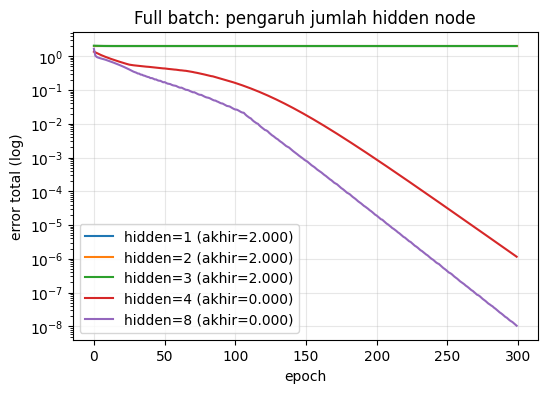

In [10]:
# Tambahan (tidak ada di buku): full batch + pengaruh ukuran hidden layer
import matplotlib.pyplot as plt

def latih_full_batch(hidden_size, alpha=0.2, epochs=300, seed=1):
    np.random.seed(seed)
    w01 = 2*np.random.random((3, hidden_size)) - 1
    w12 = 2*np.random.random((hidden_size, 1)) - 1
    hist = []
    for _ in range(epochs):
        l0 = streetlights                       # seluruh dataset sekaligus (4x3)
        l1 = relu(l0.dot(w01))
        l2 = l1.dot(w12)
        d2 = (l2 - walk_vs_stop)
        d1 = d2.dot(w12.T) * relu2deriv(l1)
        w12 -= alpha * l1.T.dot(d2) / len(l0)    # rata-rata gradien (full batch)
        w01 -= alpha * l0.T.dot(d1) / len(l0)
        hist.append(float((d2 ** 2).sum()))
    return hist

plt.figure(figsize=(6, 4))
for h in [1, 2, 3, 4, 8]:
    riwayat = latih_full_batch(h)
    plt.plot(riwayat, label=f'hidden={h} (akhir={riwayat[-1]:.3f})')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('error total (log)')
plt.legend(); plt.grid(alpha=0.3); plt.title('Full batch: pengaruh jumlah hidden node')
plt.show()

**Interpretasi:** dengan `seed = 1`, jaringan berisi 1, 2, atau 3 *hidden node* **macet pada error = 2,0** (sama dengan jumlah kuadrat target), artinya prediksinya selalu 0: semua *hidden node* kebetulan "mati" (keluaran ReLU = 0 untuk semua input), sehingga tidak ada gradien yang mengalir (*dying ReLU*). Dengan 4 atau 8 *hidden node*, error turun hingga ≈ 0. Jadi jumlah *hidden node* dan **inisialisasi bobot acak** sama-sama berpengaruh: lebih banyak node meningkatkan peluang ada node yang aktif dan memberi kapasitas lebih besar untuk menciptakan korelasi perantara. Versi *full batch* menggunakan gradien rata-rata (lebih halus), tetapi bobot diperbarui lebih jarang dibanding *stochastic*.

> **Mengapa *deep network* penting?** Deret layer memungkinkan jaringan **menciptakan korelasi bertingkat**: layer awal mendeteksi pola sederhana, layer berikutnya menggabungkannya menjadi pola lebih kompleks. Inilah dasar kekuatan deep learning di bab-bab berikutnya.

---
## 10. Ringkasan Bab

- Bila **tidak ada korelasi langsung**, *hidden layer* dibutuhkan untuk **menciptakan korelasi**.
- Dua layer linear = satu layer linear, sehingga dibutuhkan **nonlinearitas** (ReLU).
- ***Backpropagation***: `layer_1_delta = layer_2_delta · W_12ᵀ ⊙ relu'(layer_1)`, lalu `weight_delta = layerᵀ · delta`.

### Rangkuman konsep
| Subbab | Konsep | Kode |
|---|---|---|
| Streetlight problem | Matriks data, korelasi | `streetlights`, `walk_vs_stop` |
| Seluruh dataset | Stochastic / full batch / batch GD | loop per baris |
| Up & down pressure | Jaringan belajar korelasi | bobot akhir ≈ [0, 1, 0] |
| Hidden layer | Menciptakan korelasi | `weights_0_1`, `weights_1_2` |
| Nonlinearitas | ReLU | `relu(x)`, `relu2deriv` |
| Backpropagation | Atribusi error jarak jauh | `layer_1_delta` |
| Verifikasi | Gradien numerik | Selisih ≈ 0 |